In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("data/final_nutrition_dataset_balanced.csv")

In [4]:
df.head()

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml),Unnamed: 12,nutrition_risk,Disease,Portion_Size_g,Meal_ID,Day_Type,Log_Index,Confidence_Level
0,Manicotti (2 shells cheese),Meal/Pasta,380,20.739158,35.167759,18.428677,3.986625,7.176264,633.419795,58.756822,Dinner,0,NaN,Unhealthy,"Hypertension, Obesity",200,178,Weekend,1619,Medium
1,Tuna Sauce (2 tbsp),Condiment,100,4.105962,1.015272,8.830426,0.000000,0.515085,193.635879,14.933727,Lunch,0,NaN,Healthy,Healthy,250,158,Weekday,2542,High
2,Vitello Tonnato (1 serving),Meal/Meat,380,36.296747,2.877859,25.255635,0.500300,1.026956,609.421971,105.255864,Lunch,0,NaN,Unhealthy,"Hypertension, Obesity, Heart Disease",180,161,Weekday,3456,Medium
3,Tuna Melt,Meal/Processed,450,24.957741,32.002888,25.082233,3.136074,3.983427,923.167369,48.913468,Lunch,250,NaN,Unhealthy,"Hypertension, Obesity, Heart Disease",100,101,Weekend,7470,Medium
4,Ice Cream (1/2 cup vanilla),Dairy/Dessert,145,2.564908,17.387051,7.872721,0.487351,16.461352,57.653859,29.306213,Snack,0,NaN,Moderate,Diabetes,100,95,Weekend,3853,High


In [5]:
print("Before:", df.shape)

Before: (19626, 20)


In [6]:
df = df.drop(columns=[
    "Unnamed: 12",
    "Meal_ID",
    "Log_Index",
    "Confidence_Level"
], errors="ignore")

In [7]:
print("after:", df.shape)

after: (19626, 16)


In [8]:
print(df["nutrition_risk"].value_counts())

nutrition_risk
Unhealthy    6542
Healthy      6542
Moderate     6542
Name: count, dtype: int64


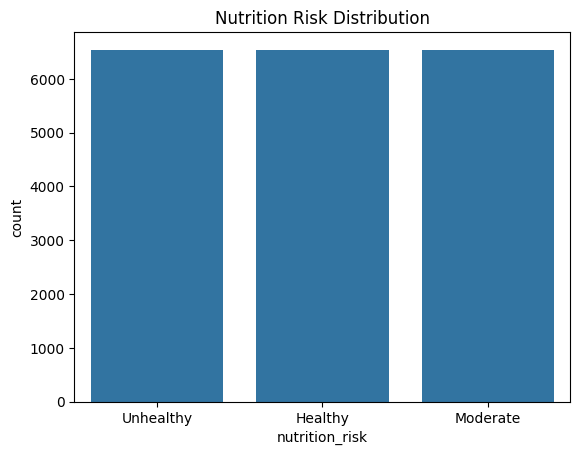

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="nutrition_risk", data=df)
plt.title("Nutrition Risk Distribution")
plt.show()

In [10]:
df.describe()

,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Portion_Size_g
count,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000,19626.000000
mean,256.098899,11.539899,23.719966,12.744978,2.154193,7.668000,439.342129,41.095107,176.467951
std,182.230948,13.678019,18.352951,11.185939,1.935414,9.752359,380.026371,60.085423,50.664254
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000
25%,97.000000,1.655246,4.834814,1.187857,0.482395,1.017687,62.518757,0.000000,150.000000
50%,220.000000,6.572627,25.000000,11.122143,2.018084,3.938070,363.667687,20.119641,180.000000
75%,400.000000,19.296950,36.472699,21.612116,3.070985,9.353487,765.605637,61.535349,200.000000
max,680.000000,206.512683,73.187593,41.969257,14.621514,61.469069,1650.136180,466.181073,250.000000


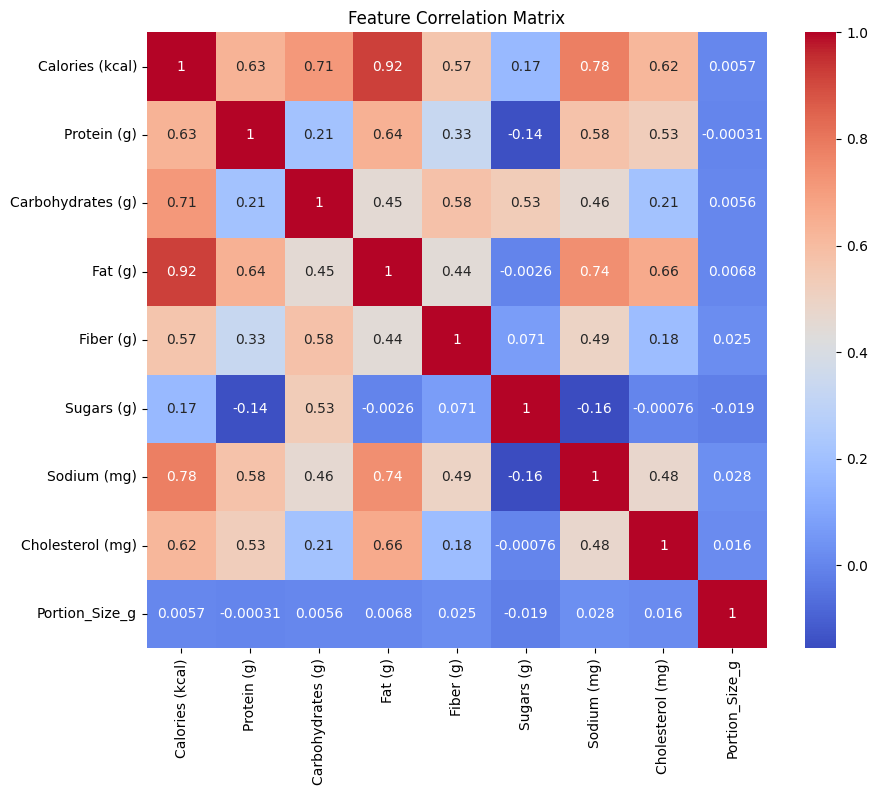

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

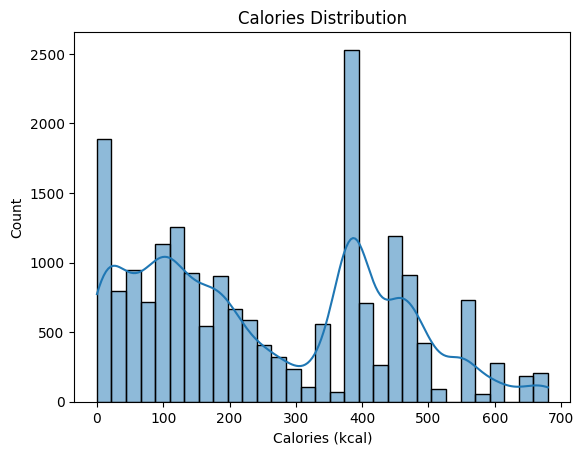

In [12]:
sns.histplot(df["Calories (kcal)"], kde=True)
plt.title("Calories Distribution")
plt.show()

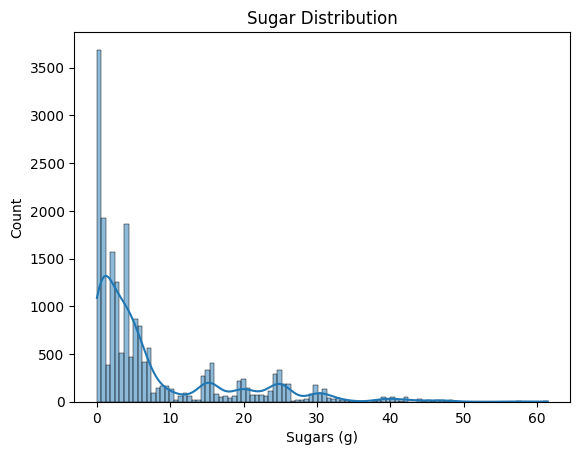

In [13]:
sns.histplot(df["Sugars (g)"], kde=True)
plt.title("Sugar Distribution")
plt.show()

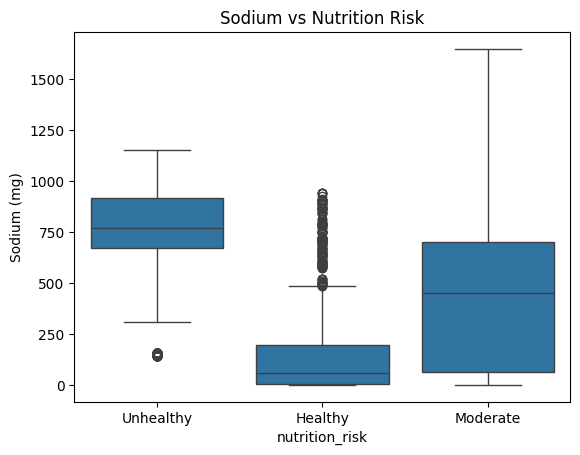

In [14]:
sns.boxplot(x="nutrition_risk", y="Sodium (mg)", data=df)
plt.title("Sodium vs Nutrition Risk")
plt.show()

In [15]:
X = df.drop("nutrition_risk", axis=1)
print(X.columns)
print(X.dtypes)

Index(['Food_Item', 'Category', 'Calories (kcal)', 'Protein (g)',
       'Carbohydrates (g)', 'Fat (g)', 'Fiber (g)', 'Sugars (g)',
       'Sodium (mg)', 'Cholesterol (mg)', 'Meal_Type', 'Water_Intake (ml)',
       'Disease', 'Portion_Size_g', 'Day_Type'],
      dtype='object')
Food_Item             object
Category              object
Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Fiber (g)            float64
Sugars (g)           float64
Sodium (mg)          float64
Cholesterol (mg)     float64
Meal_Type             object
Water_Intake (ml)     object
Disease               object
Portion_Size_g         int64
Day_Type              object
dtype: object


In [16]:
FEATURES = [
    "Calories (kcal)",
    "Protein (g)",
    "Carbohydrates (g)",
    "Fat (g)",
    "Fiber (g)",
    "Sugars (g)",
    "Sodium (mg)",
    "Water_Intake (ml)"
]

X = df[FEATURES].copy()
y = df["nutrition_risk"].copy()

In [17]:
print(X.dtypes)

Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Fiber (g)            float64
Sugars (g)           float64
Sodium (mg)          float64
Water_Intake (ml)     object
dtype: object


In [18]:
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(0)

In [19]:
print(X.dtypes)

Calories (kcal)        int64
Protein (g)          float64
Carbohydrates (g)    float64
Fat (g)              float64
Fiber (g)            float64
Sugars (g)           float64
Sodium (mg)          float64
Water_Intake (ml)    float64
dtype: object


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=2000)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [26]:
lr_pred = lr.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nClassification Report:\n",
      classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8604177279673968

Classification Report:
               precision    recall  f1-score   support

     Healthy       0.89      0.92      0.91      1308
    Moderate       0.81      0.76      0.78      1309
   Unhealthy       0.87      0.90      0.89      1309

    accuracy                           0.86      3926
   macro avg       0.86      0.86      0.86      3926
weighted avg       0.86      0.86      0.86      3926



In [27]:
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, dt_pred))

print("\nClassification Report:\n",
      classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.999745287824758

Classification Report:
               precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1308
    Moderate       1.00      1.00      1.00      1309
   Unhealthy       1.00      1.00      1.00      1309

    accuracy                           1.00      3926
   macro avg       1.00      1.00      1.00      3926
weighted avg       1.00      1.00      1.00      3926



In [28]:
rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nClassification Report:\n",
      classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.999745287824758

Classification Report:
               precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00      1308
    Moderate       1.00      1.00      1.00      1309
   Unhealthy       1.00      1.00      1.00      1309

    accuracy                           1.00      3926
   macro avg       1.00      1.00      1.00      3926
weighted avg       1.00      1.00      1.00      3926



In [29]:
print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))

Logistic Regression: 0.8604177279673968
Decision Tree: 0.999745287824758
Random Forest: 0.999745287824758


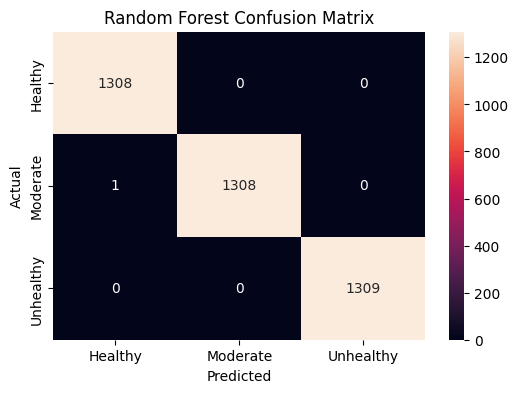

In [30]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=["Healthy","Moderate","Unhealthy"],
            yticklabels=["Healthy","Moderate","Unhealthy"])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
import joblib

joblib.dump(rf, "model/nutrition_risk_model.pkl")
joblib.dump(scaler, "model/scaler.pkl")

['model/scaler.pkl']

In [32]:
print(rf.feature_names_in_)

['Calories (kcal)' 'Protein (g)' 'Carbohydrates (g)' 'Fat (g)' 'Fiber (g)'
 'Sugars (g)' 'Sodium (mg)' 'Water_Intake (ml)']


In [33]:
import pandas as pd

pizza_sample = pd.DataFrame([{
    "Calories (kcal)": 800,
    "Protein (g)": 20,
    "Carbohydrates (g)": 90,
    "Fat (g)": 40,
    "Fiber (g)": 5,
    "Sugars (g)": 12,
    "Sodium (mg)": 1200,
    "Water_Intake (ml)": 200
}])

prediction = rf.predict(pizza_sample)
print("Prediction:", prediction[0])

Prediction: Moderate


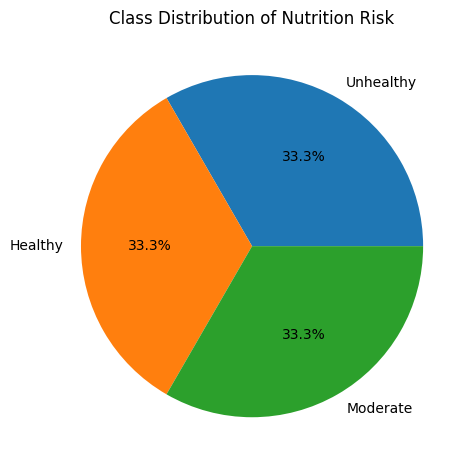

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/final_nutrition_dataset_balanced.csv")

class_counts = df["nutrition_risk"].value_counts()

plt.figure()
plt.pie(class_counts, labels=class_counts.index, autopct="%1.1f%%")
plt.title("Class Distribution of Nutrition Risk")
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

df = pd.read_csv("data/final_nutrition_dataset_balanced.csv")
print(df.head())

                     Food_Item        Category  Calories (kcal)  Protein (g)  \
0  Manicotti (2 shells cheese)      Meal/Pasta              380    20.739158   
1          Tuna Sauce (2 tbsp)       Condiment              100     4.105962   
2  Vitello Tonnato (1 serving)       Meal/Meat              380    36.296747   
3                    Tuna Melt  Meal/Processed              450    24.957741   
4  Ice Cream (1/2 cup vanilla)   Dairy/Dessert              145     2.564908   

   Carbohydrates (g)    Fat (g)  Fiber (g)  Sugars (g)  Sodium (mg)  \
0          35.167759  18.428677   3.986625    7.176264   633.419795   
1           1.015272   8.830426   0.000000    0.515085   193.635879   
2           2.877859  25.255635   0.500300    1.026956   609.421971   
3          32.002888  25.082233   3.136074    3.983427   923.167369   
4          17.387051   7.872721   0.487351   16.461352    57.653859   

   Cholesterol (mg) Meal_Type Water_Intake (ml)  Unnamed: 12 nutrition_risk  \
0         58.

In [38]:
X = df[['Calories (kcal)', 'Protein (g)', 'Carbohydrates (g)', 
        'Fat (g)', 'Sugars (g)']]

In [39]:
y = df['nutrition_risk']

In [40]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Healthy' 'Moderate' 'Unhealthy']


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    class_weight='balanced',
    n_estimators=200,
    random_state=42
)

model.fit(X_scaled, y_encoded)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [43]:
import joblib

joblib.dump(model, "nutrition_risk_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [44]:
sample = [[450, 25, 32, 25, 4]]  # like Tuna Melt
sample_scaled = scaler.transform(sample)

pred = model.predict(sample_scaled)
print(label_encoder.inverse_transform(pred))

['Unhealthy']


C:\Users\sailu\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [45]:
import pandas as pd

sample = pd.DataFrame([[450, 25, 32, 25, 4]],
                      columns=['Calories (kcal)', 'Protein (g)', 
                               'Carbohydrates (g)', 'Fat (g)', 'Sugars (g)'])

sample_scaled = scaler.transform(sample)
pred = model.predict(sample_scaled)

print(label_encoder.inverse_transform(pred))

['Unhealthy']


In [46]:
print("MODEL RAW OUTPUT:", model.predict(X_scaled))

MODEL RAW OUTPUT: [2 0 2 ... 0 0 2]


In [50]:
ml_risk_encoded = model.predict(X_scaled)[0]

In [51]:
print("Encoded:", ml_risk_encoded)

Encoded: 2
